## 46-886

## Regularization: Ridge and Lasso Regression

### Application: Predicting Diabetes Disease Progression
 

Amr Farahat

CMU / Tepper

2023-04-10

---

## 0. Setting up

In [46]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

In [47]:
import statsmodels.api as sm
from graphviz import Source
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.tree import DecisionTreeRegressor
from sklearn.tree import export_graphviz
from sklearn.ensemble import RandomForestRegressor
from sklearn.ensemble import GradientBoostingRegressor
from sklearn.model_selection import cross_val_score
from sklearn.model_selection import GridSearchCV
from sklearn.metrics import mean_squared_error

In [48]:
# new imports
from sklearn.linear_model import Ridge
from sklearn.linear_model import Lasso
from sklearn.linear_model import ElasticNet
from sklearn.linear_model import RidgeCV
from sklearn.linear_model import LassoCV
from sklearn.linear_model import ElasticNetCV

In [49]:
pd.options.display.max_columns = None

In [50]:
def OSR2(y_actual,y_pred,baseline):
    residuals = y_actual - y_pred
    SSR = np.sum((residuals)^2)
    SST = np.sum((y_actual - baseline)^2)
    R2 = 1 - SSR / SST
    return(R2) 

## 1. Reading in data

Original data can be found here: 
https://hastie.su.domains/StatLearnSparsity_files/DATA/diabetes.html

We will use a standardized version that includes quadratic and interaction terms. 

The data is standardized as follows:
1. Standardizing the 10 main indep vars
2. Creating quadratic+interaction terms
3. Re-standardizing the quadratic/interaction terms

In [51]:
df = pd.read_csv("df.csv")

In [52]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 442 entries, 0 to 441
Data columns (total 66 columns):
 #   Column   Non-Null Count  Dtype  
---  ------   --------------  -----  
 0   all.obs  442 non-null    int64  
 1   y        442 non-null    int64  
 2   age      442 non-null    float64
 3   sex      442 non-null    float64
 4   bmi      442 non-null    float64
 5   map      442 non-null    float64
 6   tc       442 non-null    float64
 7   ldl      442 non-null    float64
 8   hdl      442 non-null    float64
 9   tch      442 non-null    float64
 10  ltg      442 non-null    float64
 11  glu      442 non-null    float64
 12  age^2    442 non-null    float64
 13  bmi^2    442 non-null    float64
 14  map^2    442 non-null    float64
 15  tc^2     442 non-null    float64
 16  ldl^2    442 non-null    float64
 17  hdl^2    442 non-null    float64
 18  tch^2    442 non-null    float64
 19  ltg^2    442 non-null    float64
 20  glu^2    442 non-null    float64
 21  age:sex  442 non

The dataframe has been split in a 70% train sample and a 30% test sample in the files <df_train.csv> and <df_test.csv>

In [53]:
df

,all.obs,y,age,sex,bmi,map,tc,ldl,hdl,tch,ltg,glu,age^2,bmi^2,map^2,tc^2,ldl^2,hdl^2,tch^2,ltg^2,glu^2,age:sex,age:bmi,age:map,age:tc,age:ldl,age:hdl,age:tch,age:ltg,age:glu,sex:bmi,sex:map,sex:tc,sex:ldl,sex:hdl,sex:tch,sex:ltg,sex:glu,bmi:map,bmi:tc,bmi:ldl,bmi:hdl,bmi:tch,bmi:ltg,bmi:glu,map:tc,map:ldl,map:hdl,map:tch,map:ltg,map:glu,tc:ldl,tc:hdl,tc:tch,tc:ltg,tc:glu,ldl:hdl,ldl:tch,ldl:ltg,ldl:glu,hdl:tch,hdl:ltg,hdl:glu,tch:ltg,tch:glu,ltg:glu
0,1,151,0.038076,0.050680,0.061696,0.021872,-0.044223,-0.034821,-0.043401,-0.002592,0.019908,-0.017646,-0.014855,0.022505,-0.031045,-0.004331,-0.013740,-0.004631,-0.030448,-0.028816,-0.027526,0.032865,0.040572,0.001661,-0.046553,-0.038245,-0.034512,-0.012112,0.003065,-0.030278,0.062103,0.012282,-0.048572,-0.044124,-0.030804,-0.019548,0.014227,-0.029386,0.009001,-0.071718,-0.060318,-0.041358,-0.024034,0.004826,-0.041028,-0.032721,-0.025747,-0.011207,-0.013825,-0.010194,-0.025778,-0.006869,0.039823,-0.019303,-0.042892,0.000963,0.042355,-0.022038,-0.031125,-0.000922,0.033494,0.000852,0.031150,-0.028191,-0.017658,-0.027794
1,2,75,-0.001882,-0.044642,-0.051474,-0.026328,-0.008449,-0.019163,0.074412,-0.039493,-0.068330,-0.092204,-0.041292,0.005643,-0.027308,-0.030939,-0.024801,0.040037,-0.009485,0.037161,0.088022,-0.006610,-0.006765,-0.015934,-0.011729,-0.009656,0.000700,-0.008369,-0.010202,-0.011380,0.044518,0.013739,0.006223,0.011262,-0.056568,0.022402,0.057588,0.078464,0.009115,-0.002836,0.008710,-0.067155,0.024046,0.055299,0.080609,-0.007040,0.001846,-0.031979,0.009875,0.020370,0.031362,-0.026235,-0.016462,-0.015501,-0.012343,0.000933,-0.021256,-0.011564,0.012973,0.023783,-0.023815,-0.094506,-0.140378,0.025298,0.053034,0.104013
2,3,141,0.085299,0.050680,0.044451,-0.005671,-0.045599,-0.034194,-0.032356,-0.002592,0.002864,-0.025930,0.091643,-0.004176,-0.038810,-0.002586,-0.014306,-0.014861,-0.030448,-0.034810,-0.022433,0.084052,0.070889,-0.027913,-0.091744,-0.071642,-0.060292,-0.014761,-0.007764,-0.064699,0.043562,-0.018158,-0.050032,-0.043453,-0.017955,-0.019548,-0.004122,-0.038423,-0.022692,-0.056443,-0.046482,-0.013617,-0.023054,-0.019451,-0.042361,-0.006260,-0.004923,0.012093,-0.012282,-0.020318,-0.014953,-0.006597,0.030017,-0.019241,-0.027178,0.009872,0.033587,-0.022063,-0.018016,0.004913,0.032956,0.018281,0.032795,-0.027332,-0.017236,-0.022304
3,4,206,-0.089063,-0.044642,-0.011595,-0.036656,0.012191,0.024991,-0.036038,0.034309,0.022692,-0.009362,0.103640,-0.031017,-0.015987,-0.029848,-0.021434,-0.011783,-0.014650,-0.026985,-0.030682,0.076629,0.012903,0.056290,-0.034299,-0.057136,0.078681,-0.076082,-0.055509,0.003379,0.006750,0.023794,-0.013059,-0.030403,0.056619,-0.050555,-0.028722,-0.001140,-0.009293,-0.015383,-0.019392,0.027927,-0.029250,-0.028060,-0.016069,-0.021487,-0.029114,0.035493,-0.039783,-0.038599,-0.010970,-0.024229,-0.012279,-0.014033,-0.018644,-0.018858,-0.009878,-0.009984,-0.003373,-0.019109,0.008159,0.001898,0.021514,-0.012045,-0.024872,-0.025042
4,5,135,0.005383,-0.044642,-0.036385,0.021872,0.003935,0.015596,0.008142,-0.002592,-0.031991,-0.046641,-0.040827,-0.013681,-0.031045,-0.031728,-0.026424,-0.026851,-0.030448,-0.019132,-0.001228,-0.013547,-0.012917,-0.014402,-0.011621,-0.008650,0.004980,-0.010279,-0.016542,-0.020871,0.030227,-0.033184,-0.005346,-0.021538,0.011345,-0.014076,0.023131,0.034682,-0.033452,-0.015423,-0.025507,0.011944,-0.018459,0.003409,0.017045,-0.009984,-0.001715,0.011983,-0.013825,-0.035639,-0.038658,-0.027648,-0.001867,-0.021470,-0.027079,-0.020396,0.012376,-0.024091,-0.026846,-0.029687,0.030984,0.014489,0.005386,-0.025575,-0.016180,0.008735
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
437,438,178,0.041708,0.050680,0.019662,0.059744,-0.005697,-0.002566,-0.028674,-0.002592,0.031193,0.007207,-0.009557,-0.027342,0.022742,-0.031

In [8]:
df_train = pd.read_csv("df_train.csv")
df_test = pd.read_csv("df_test.csv")

In [9]:
df_train.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 309 entries, 0 to 308
Data columns (total 66 columns):
 #   Column     Non-Null Count  Dtype  
---  ------     --------------  -----  
 0   train.obs  309 non-null    int64  
 1   y          309 non-null    int64  
 2   age        309 non-null    float64
 3   sex        309 non-null    float64
 4   bmi        309 non-null    float64
 5   map        309 non-null    float64
 6   tc         309 non-null    float64
 7   ldl        309 non-null    float64
 8   hdl        309 non-null    float64
 9   tch        309 non-null    float64
 10  ltg        309 non-null    float64
 11  glu        309 non-null    float64
 12  age^2      309 non-null    float64
 13  bmi^2      309 non-null    float64
 14  map^2      309 non-null    float64
 15  tc^2       309 non-null    float64
 16  ldl^2      309 non-null    float64
 17  hdl^2      309 non-null    float64
 18  tch^2      309 non-null    float64
 19  ltg^2      309 non-null    float64
 20  glu^2     

In [10]:
y_train = df_train["y"]
X_train = df_train.drop(["y","train.obs"], axis=1)
y_test = df_test["y"]
X_test = df_test.drop(["y","test.obs"], axis=1)

In [11]:
baseline = np.mean(y_train)

## 3. Some (Un-regularized) Linear Regression Models

I'll ignore multi-collinearity in the interest of time,
(Note: In Ridge and LASSO regression below, we don't normally check for multi-collinearity)

#### M0: All 64 variables

In [12]:
lr_mod0 = LinearRegression()
lr_mod0.fit(X_train, y_train)

LinearRegression()

In [13]:
print("Linear Regression train R2: ", lr_mod0.score(X_train, y_train))
print("Linear Regression test R2: ", lr_mod0.score(X_test, y_test))

Linear Regression train R2:  0.6307558171804575
Linear Regression test R2:  0.33911687167392035


In [14]:
y_pred = lr_mod0.predict(X_train)

#### M2: Only the 6 serum variables

In [15]:
mod2_vars = ["tc","ldl","hdl","tch","ltg","glu"]

In [16]:
X_train_mod2 = X_train[mod2_vars]
X_test_mod2 = X_test[mod2_vars]

In [17]:
lr_mod2 = LinearRegression()
lr_mod2.fit(X_train_mod2, y_train)

LinearRegression()

In [18]:
print("Linear Regression train R2: ", lr_mod2.score(X_train_mod2, y_train))
print("Linear Regression test R2: ", lr_mod2.score(X_test_mod2, y_test))

Linear Regression train R2:  0.36663416413717786
Linear Regression test R2:  0.3873010981999875


## 4. Ridge Regression

https://scikit-learn.org/stable/modules/generated/sklearn.linear_model.Ridge.html

In [19]:
ridge_mod = Ridge(alpha=1, solver="cholesky")

In [20]:
ridge_mod.fit(X_train, y_train)

Ridge(alpha=1, solver='cholesky')

Note: Can use the predict() and get_params() methods

In [21]:
print("Ridge Regression train R2: ", ridge_mod.score(X_train, y_train))
print("Ridge Regression test R2: ", ridge_mod.score(X_test, y_test))

Ridge Regression train R2:  0.4999380038944101
Ridge Regression test R2:  0.3863128498481291


#### With CV

In [22]:
alphas=np.logspace(-1, 2, 4)

In [23]:
ridge_mod_cv = RidgeCV(alphas=alphas, store_cv_values=True)

In [24]:
ridge_mod_cv.fit(X_train, y_train)

RidgeCV(alphas=array([  0.1,   1. ,  10. , 100. ]), store_cv_values=True)

In [25]:
ridge_mod_cv.alpha_

0.1

In [26]:
#ridge_mod_cv.cv_values_

In [27]:
print("Ridge Regression with CV train R2: ", ridge_mod_cv.score(X_train, y_train))
print("Ridge Regression with CV test R2: ", ridge_mod_cv.score(X_test, y_test))

Ridge Regression with CV train R2:  0.601514213757482
Ridge Regression with CV test R2:  0.42276773019551384


#### Compute and Display Paths

In [54]:
alphas=np.logspace(-5, +10, 16, base=np.e)

In [55]:
coefs = []
for a in alphas:
    ridge = Ridge(alpha=a, solver="cholesky")
    ridge.fit(X_train, y_train)
    coefs.append(ridge.coef_)

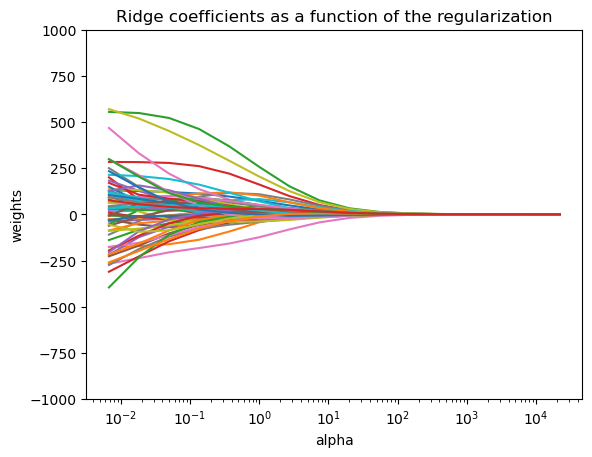

In [56]:
ax = plt.gca()
ax.plot(alphas, coefs)
ax.set_xscale("log")
plt.ylim(-1000, +1000)
plt.xlabel("alpha")
plt.ylabel("weights")
plt.title("Ridge coefficients as a function of the regularization")
#plt.axis("tight")
plt.show()

Perhaps a better graphing code:
https://scikit-learn.org/stable/auto_examples/linear_model/plot_lasso_coordinate_descent_path.html#sphx-glr-auto-examples-linear-model-plot-lasso-coordinate-descent-path-py

## 5. LASSO Regression

https://scikit-learn.org/stable/modules/generated/sklearn.linear_model.Lasso.html

In [31]:
lasso_mod = Lasso(alpha=1)

In [32]:
lasso_mod.fit(X_train, y_train)

Lasso(alpha=1)

Note: Can use the predict() and get_params() methods

In [33]:
print("LASSO Regression train R2: ", lasso_mod.score(X_train, y_train))
print("LASSO Regression test R2: ", lasso_mod.score(X_test, y_test))

LASSO Regression train R2:  0.38907707594305985
LASSO Regression test R2:  0.31364192994133555


#### With CV

In [34]:
alphas=np.logspace(-1, 2, 4)

In [35]:
lasso_mod_cv = LassoCV(alphas=alphas)

In [36]:
lasso_mod_cv.fit(X_train, y_train)

LassoCV(alphas=array([  0.1,   1. ,  10. , 100. ]))

In [37]:
lasso_mod_cv.alpha_

0.1

In [38]:
print("LASSO Regression with CV train R2: ", lasso_mod_cv.score(X_train, y_train))
print("LASSO Regression with CV test R2: ", lasso_mod_cv.score(X_test, y_test))

LASSO Regression with CV train R2:  0.5730385944532028
LASSO Regression with CV test R2:  0.4392288550837622


#### Compute and Display Paths

In [39]:
alphas=np.logspace(-5, +5, 11, base=np.e)

In [40]:
coefs = []
for a in alphas:
    lasso = Lasso(alpha=a)
    lasso.fit(X_train, y_train)
    coefs.append(lasso.coef_)

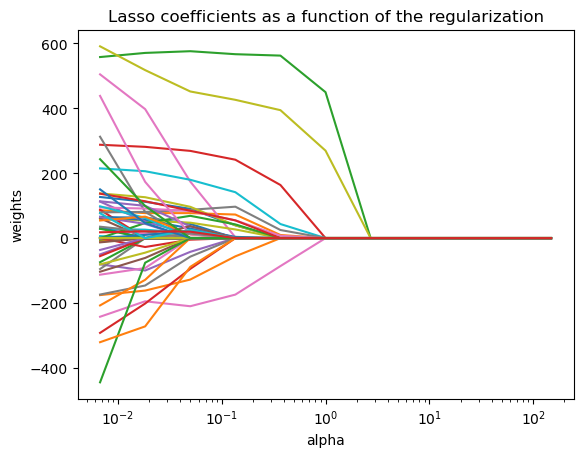

In [41]:
ax = plt.gca()
ax.plot(alphas, coefs)
ax.set_xscale("log")
plt.ylim(-1000, +1000)
plt.xlabel("alpha")
plt.ylabel("weights")
plt.title("Lasso coefficients as a function of the regularization")
plt.axis("tight")
plt.show()

## 6. ElasticNet Regression

https://scikit-learn.org/stable/modules/generated/sklearn.linear_model.ElasticNet.html

In [42]:
elasticNet_mod = ElasticNet(alpha=0.1, l1_ratio=0.5)
elasticNet_mod.fit(X_train, y_train)

ElasticNet(alpha=0.1)

In [43]:
print("ElasticNet Regression train R2: ", elasticNet_mod.score(X_train, y_train))
print("ElasticNet Regression test R2: ", elasticNet_mod.score(X_test, y_test))

ElasticNet Regression train R2:  0.1375354305893971
ElasticNet Regression test R2:  0.10966958271575922


## END